In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, TensorDataset, DataLoader
from tab_transformer_pytorch import TabTransformer, FTTransformer
from preprocessing import get_features_and_target_classification, get_features_and_target
from sklearn.preprocessing import LabelEncoder
from RMSELoss import RMSELoss
import plotly.graph_objects as go
from tabpfn import TabPFNClassifier
from tabpfn.constants import ModelVersion
from sklearn.model_selection import train_test_split

In [2]:
import huggingface_hub
huggingface_hub.login()

# Getting Dataframe

In [3]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data_classifier.csv")
dev_df = pd.read_csv("data/development_data_classifier.csv")

#sc = StandardScaler()

target_column = ("Category")  

x_train, y_train = get_features_and_target_classification(train_df, target_column)
x_dev, y_dev = get_features_and_target_classification(dev_df, target_column)


#x_train = sc.fit_transform(X=x_train)
#x_dev = sc.transform(x_dev)


# Add Physical Columns Interfacial_Failure and Pullout_Failure

In [4]:
def compute_interfacial_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     f_pull = 1 * (np.pi/4) * (4 * np.sqrt(t))**2 * (0.7 * 365)
     return np.round(f_pull, 1) 

def compute_pullout_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     x = df[['Thickness A (mm)', 'Thickness B (mm)']].sum(axis=1)
     # x can be approximated to metal sheet thickness. Change 2*t either to t to use the thinner 
     # metal sheet or 2*x to test if the sum of both metal sheets give beter results
     f_pull = np.pi * ((4 * np.sqrt(t)) + 2*t)*t*365 
     return np.round(f_pull, 1) 

In [5]:
dev_df["Sample ID"].value_counts().sort_values().head()


Sample ID
32     3
25     3
8      3
16     3
225    4
Name: count, dtype: int64

In [6]:
x_dev

,Sample ID,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,6,95,1500,0,0.00,1213.38,0.918,0.925
1,6,95,1500,0,8.29,1230.27,0.918,0.925
2,6,95,1500,0,16.57,1217.63,0.918,0.925
3,6,95,1500,0,24.85,1111.28,0.918,0.925
4,6,95,1500,0,33.15,1126.65,0.918,0.925
...,...,...,...,...,...,...,...,...
835,489,60,1200,0,98.26,3576.75,0.625,0.624
836,489,60,1200,0,98.22,3024.94,0.625,0.624
837,489,60,1200,0,98.18,2984.87,0.625,0.624
838,489,60,1200,0,98.14,2950.68,0.625,0.624


# Fit Model

In [7]:
from sklearn.metrics import accuracy_score, roc_auc_score

# columns that vary within a sample
time_series_cols = ["Force (N)", "Current (A)"]

# static columns
static_cols = ["Pressure (PSI)", "Welding Time (ms)", "Angle (Deg)", "Thickness A (mm)", "Thickness B (mm)"]

agg_df_train = train_df.groupby("Sample ID")[time_series_cols].agg(
    ['mean', 'std', 'min', 'max']
)
agg_df_dev = dev_df.groupby("Sample ID")[time_series_cols].agg(
    ['mean', 'std', 'min', 'max']
)

# flatten multi-index columns
agg_df_train.columns = ['_'.join(col) for col in agg_df_train.columns]
agg_df_dev.columns = ['_'.join(col) for col in agg_df_dev.columns]

# --- Add static columns (take first value per sample) --- 
static_df_train = train_df.groupby("Sample ID")[static_cols].first() 
static_df_dev = dev_df.groupby("Sample ID")[static_cols].first() 

 # Total Welding Time, adds the Welding Time Cycles in a single sample
weld_time_sum_train = train_df.groupby("Sample ID")["Welding Time (ms)"].sum() 
weld_time_sum_train = weld_time_sum_train.rename("Welding_Time_Total") 
weld_time_sum_dev = dev_df.groupby("Sample ID")["Welding Time (ms)"].sum() 
weld_time_sum_dev = weld_time_sum_dev.rename("Welding_Time_Total") 

# Combination of datasets
join_static_df_train = agg_df_train.join(static_df_train) 
x_train = join_static_df_train.join(weld_time_sum_train) 
join_static_df_dev = agg_df_dev.join(static_df_dev) 
x_dev = join_static_df_dev.join(weld_time_sum_dev) 

# Target value
y_train = train_df.groupby("Sample ID")['Category'].first()

classifier = TabPFNClassifier() 

classifier.fit(x_train,y_train)

predictions = classifier.predict(x_dev)

In [8]:
#y = y.to_frame(name="Category")   # ensure y is a DataFrame
#x["Pullforce"] = None


# Add Pullforce as Target

In [9]:
pullforces = []
y_dev = dev_df.groupby("Sample ID")['Category'].first()

for sample_id, pred in zip(y_dev.index, predictions):
    row_x_df = x_dev.loc[[sample_id]]   # 1-row DataFrame

    if pred == "Bad":
        value = compute_interfacial_failure(row_x_df).iloc[0]
    else:
        value = compute_pullout_failure(row_x_df).iloc[0]
    pullforces.append(value)

pullforces = np.array(pullforces)


In [10]:
print(predictions)

['Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good']


In [11]:
print(x_train)

           Force (N)_mean  Force (N)_std  Force (N)_min  Force (N)_max  \
Sample ID                                                                
1                3.410000       3.410000           0.00           6.82   
2               25.967500      16.599982           0.00          52.25   
4                8.286667       8.285001           0.00          16.57   
5               33.136667       8.285001          24.85          41.42   
7               97.644667      21.377203          63.82         127.46   
...                   ...            ...            ...            ...   
488             98.536154       0.083520          98.34          98.63   
490             97.889231       0.283092          97.32          98.15   
492             98.490833       0.277700          98.07          98.87   
493             97.519167       0.330962          97.09          97.99   
494             96.705833       0.232553          96.34          97.05   

           Current (A)_mean  Current 

In [12]:
pullforces

array([5967. , 2960.3, 6042.8, 2976.3, 6097.2, 2976.3, 6097.2, 3018.1,
       3423.9, 3170.5, 3245.7, 3237.3, 3254.1, 3304.7, 3195.5, 3245.7,
       3153.9, 3203.8, 3087.8, 3330.1, 3245.7, 3270.9, 3162.2, 3187.1,
       3220.5, 3220.5, 3145.6, 3187.1, 3129. , 3162.2, 3096. , 3112.5,
       3220.5, 3228.9, 3096. , 3254.1, 3270.9, 3137.3, 3170.5, 3212.2,
       3137.3, 3254.1, 3228.9, 3145.6, 3212.2, 3220.5, 3254.1, 3262.5,
       3145.6, 3071.3, 3055. , 3038.6, 3178.8, 3129. , 3162.2, 3145.6,
       3170.5, 3120.8, 3162.2, 3178.8, 3153.9, 3104.3, 3137.3, 3153.9,
       3129. , 3137.3, 3096. , 3055. , 3079.6, 3137.3, 3104.3, 3220.5,
       3162.2, 3178.8, 3112.5, 3104.3, 3137.3, 3104.3, 3129. , 3187.1,
       3212.2, 3145.6, 3195.5, 3170.5, 3170.5, 3112.5, 3120.8, 3162.2,
       3153.9, 3170.5, 3038.6, 3112.5, 3153.9, 3071.3, 3153.9, 3145.6,
       3170.5, 3112.5, 3153.9])

# Check Validation Data

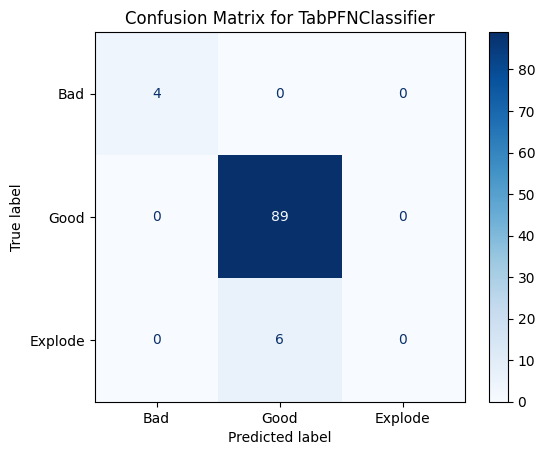

F1_Score 0.6557971014492754


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# preds = classifier.predict(X)
# y = your true labels

y_dev = dev_df.groupby("Sample ID")['Category'].first()
cm = confusion_matrix(y_dev, predictions, labels=["Bad", "Good", "Explode"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Bad", "Good", "Explode"])

disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix for TabPFNClassifier")
plt.show()


# Predict probabilities
prediction_probabilities = classifier.predict_proba(x_dev)
#print("ROC AUC:", roc_auc_score(y, prediction_probabilities[:, 1]))

# Predict labels
predictions = classifier.predict(x_dev)
print("F1_Score", f1_score(y_dev, predictions, average = "macro"))

In [14]:
y_dev = dev_df.groupby("Sample ID")['PullTest (N)'].first()
y_dev
# Convert to numpy arrays
true_vals = np.array(y_dev).ravel()
pred_vals = np.array(pullforces).ravel()

# Sample index
sample_idx = np.arange(len(true_vals))

# Extract category per sample (aligned with y_dev)
categories = dev_df.groupby("Sample ID")["Category"].first().values

# Masks
mask_good    = categories == "Good"
mask_bad     = categories == "Bad"
mask_explode = categories == "Explode"

fig = go.Figure()

# --- GOOD (circles) ---
fig.add_trace(go.Scatter(
    x=sample_idx[mask_good],
    y=true_vals[mask_good],
    mode="markers",
    name="Good (True)",
    marker=dict(symbol="circle", color="red", size=7)
))
fig.add_trace(go.Scatter(
    x=sample_idx[mask_good],
    y=pred_vals[mask_good],
    mode="markers",
    name="Good (Pred)",
    marker=dict(symbol="circle", color="blue", size=7)
))

# --- BAD (X) ---
fig.add_trace(go.Scatter(
    x=sample_idx[mask_bad],
    y=true_vals[mask_bad],
    mode="markers",
    name="Bad (True)",
    marker=dict(symbol="x", color="red", size=9)
))
fig.add_trace(go.Scatter(
    x=sample_idx[mask_bad],
    y=pred_vals[mask_bad],
    mode="markers",
    name="Bad (Pred)",
    marker=dict(symbol="x", color="blue", size=9)
))

# --- EXPLODE (triangle-up) ---
fig.add_trace(go.Scatter(
    x=sample_idx[mask_explode],
    y=true_vals[mask_explode],
    mode="markers",
    name="Explode (True)",
    marker=dict(symbol="triangle-up", color="red", size=9)
))
fig.add_trace(go.Scatter(
    x=sample_idx[mask_explode],
    y=pred_vals[mask_explode],
    mode="markers",
    name="Explode (Pred)",
    marker=dict(symbol="triangle-up", color="blue", size=9)
))

# Connecting lines
for i in range(len(sample_idx)):
    fig.add_trace(go.Scatter(
        x=[sample_idx[i], sample_idx[i]],
        y=[true_vals[i], pred_vals[i]],
        mode="lines",
        line=dict(color="gray", width=1),
        showlegend=False
    ))

fig.update_layout(
    title="Validation Samples: True vs Prediction (Pullforces) by Category",
    xaxis_title="Sample Index",
    yaxis_title="Pull Force",
    template="seaborn"
)

fig.write_html("Graphs/TabPFN_Evaltrue.html")
fig.show()



In [15]:
y_dev.head(10)

Sample ID
6     4161.4
8     1836.4
14    3970.1
16    2509.8
22    4952.0
25    2867.4
28    3855.5
32    2764.4
34    3281.1
40    3256.1
Name: PullTest (N), dtype: float64

In [16]:
predictions

array(['Good', 'Bad', 'Good', 'Bad', 'Good', 'Bad', 'Good', 'Bad', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good'], dtype=object)

In [17]:
y_dev = dev_df.groupby("Sample ID")['PullTest (N)'].first()
y_dev.head(10)

Sample ID
6     4161.4
8     1836.4
14    3970.1
16    2509.8
22    4952.0
25    2867.4
28    3855.5
32    2764.4
34    3281.1
40    3256.1
Name: PullTest (N), dtype: float64

In [18]:
pullforces

array([5967. , 2960.3, 6042.8, 2976.3, 6097.2, 2976.3, 6097.2, 3018.1,
       3423.9, 3170.5, 3245.7, 3237.3, 3254.1, 3304.7, 3195.5, 3245.7,
       3153.9, 3203.8, 3087.8, 3330.1, 3245.7, 3270.9, 3162.2, 3187.1,
       3220.5, 3220.5, 3145.6, 3187.1, 3129. , 3162.2, 3096. , 3112.5,
       3220.5, 3228.9, 3096. , 3254.1, 3270.9, 3137.3, 3170.5, 3212.2,
       3137.3, 3254.1, 3228.9, 3145.6, 3212.2, 3220.5, 3254.1, 3262.5,
       3145.6, 3071.3, 3055. , 3038.6, 3178.8, 3129. , 3162.2, 3145.6,
       3170.5, 3120.8, 3162.2, 3178.8, 3153.9, 3104.3, 3137.3, 3153.9,
       3129. , 3137.3, 3096. , 3055. , 3079.6, 3137.3, 3104.3, 3220.5,
       3162.2, 3178.8, 3112.5, 3104.3, 3137.3, 3104.3, 3129. , 3187.1,
       3212.2, 3145.6, 3195.5, 3170.5, 3170.5, 3112.5, 3120.8, 3162.2,
       3153.9, 3170.5, 3038.6, 3112.5, 3153.9, 3071.3, 3153.9, 3145.6,
       3170.5, 3112.5, 3153.9])

# Check Validation Loss and R2

In [19]:
# Calculate MAE and RMSE and R2
mae  = mean_absolute_error(y_dev, pullforces)
rmse = np.sqrt(mean_squared_error(y_dev, pullforces))
R2   = r2_score(y_dev, pullforces)


print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {R2:.2f}")

MAE:  332.56
RMSE: 501.80
R2: -0.98
